### Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!apt-get install unrar tree
!pip install ipecharts

### Data Extract

In [ ]:
!unrar x /content/drive/MyDrive/TUKL/data_online_line_width_alpha.rar "*.csv" /content/
!mv /content/data_online_line_width_alpha/ /content/hwd/

In [4]:
!tree -L 1 /content/hwd/

/content/hwd/
├── Dataset
├── main_1000.csv
├── main_1500.csv
├── main_2000.csv
├── main_2500.csv
├── main_3000.csv
├── main_3500.csv
├── main_5000.csv
├── main_6000.csv
├── test.csv
├── test_extended.csv
├── test_leakproof.csv
├── test_leakproof_raw.csv
├── train.csv
├── train_extended.csv
├── train_leakproof.csv
├── train_leakproof_raw.csv
├── val.csv
├── val_extended.csv
├── val_leakproof.csv
└── val_leakproof_raw.csv

1 directory, 20 files


In [5]:
import pandas as pd

df = pd.read_csv('/content/hwd/main_1500.csv')
print(df.shape)
df.head(2)

(253, 7)


,id,cms,gender,age,csv,img,line
0,0,461136,f,21,Dataset/Data_1500/csv/csv_0000_0.csv,Dataset/Data_1500/img/img_0000_0.png,پڑھی گئیں کہ ٹرکوں کے ٹرک امدادی سامان سے بھرے
1,0,461136,f,21,Dataset/Data_1500/csv/csv_0000_1.csv,Dataset/Data_1500/img/img_0000_1.png,نہ دیتا تو آپؒ اس پر ناراضگی کا اظہار کرتے


In [6]:
data = pd.read_csv('/content/hwd/Dataset/Data_1500/csv/csv_0000_0.csv')
data.head()[['X cood.','Y cood.','Time']]

,X cood.,Y cood.,Time
0,15527,519,0
1,15468,518,2
2,15453,515,4
3,15440,504,6
4,15423,486,8


In [7]:
binned = pd.cut(data['pen_down'], bins=10)

# Count per bin
counts = binned.value_counts().sort_index()
print(counts)

pen_down
(-0.001, 0.1]    6342
(0.1, 0.2]          0
(0.2, 0.3]          0
(0.3, 0.4]          0
(0.4, 0.5]          0
(0.5, 0.6]          0
(0.6, 0.7]          0
(0.7, 0.8]          0
(0.8, 0.9]          0
(0.9, 1.0]       8387
Name: count, dtype: int64


### Data Prep

In [8]:
import glob
import pandas as pd

# Combine main files into one dataframe
main_files = glob.glob('/content/hwd/main_*.csv')
main_files_df = pd.concat((pd.read_csv(f) for f in main_files), ignore_index=True)

main_files_df.head()

,id,gender,age,csv,img,line,cms
0,0,m,19,Dataset/Data_3000/csv/csv_0000_0.csv,Dataset/Data_3000/img/img_0000_0.png,اے قوانین کے مطابق عمل کرنا ضروری ہے۔,NaN
1,0,m,19,Dataset/Data_3000/csv/csv_0000_1.csv,Dataset/Data_3000/img/img_0000_1.png,انہوں نے لئے۔ کئی دِر بنا رکھے ہیں۔ایکِ طریقہ تو,NaN
2,0,m,19,Dataset/Data_3000/csv/csv_0000_2.csv,Dataset/Data_3000/img/img_0000_2.png,یہ ہے اور ویگنوں میں سفر کرنے والی خواتین,NaN
3,0,m,19,Dataset/Data_3000/csv/csv_0000_3.csv,Dataset/Data_3000/img/img_0000_3.png,مردوں کے ساتھ تاحال فنڈز جاری نہیں ہو سکے۔,NaN
4,0,m,19,Dataset/Data_3000/csv/csv_0000_4.csv,Dataset/Data_3000/img/img_0000_4.png,اسی طرح قلات ڈویژن بھر میں ایسے روبوٹس تیار کی...,NaN


In [ ]:
import pandas as pd
import glob

meta_files = glob.glob('/content/hwd/main_*.csv')
samples = []
for f in meta_files:
    df = pd.read_csv(f)
    full_paths = '/content/hwd/' + df['csv']
    samples.extend(full_paths.tolist())

# Write the list to a file that bash can read
with open('/content/samples.txt', 'w') as f:
    f.write('\n'.join(samples))

print(f"Extracted {len(samples)} data files")

Extracted 2403 data files


In [ ]:
%%bash
out="/content/combined.csv"
file_list="/content/data_files.txt"

# Write header from the first data file
head -1 "$(head -1 $file_list)" > "$out"

# Append the rest, skipping every file’s header
while IFS= read -r f; do
    tail -n +2 "$f" >> "$out"
done < "$file_list"

echo "Done – combined.csv created ($(wc -l < "$out") lines)"

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def process_sample(file_path, distance = 120) -> np.ndarray:
    df = pd.read_csv(file_path, usecols=['X cood.','Y cood.','Time', 'pen_down'])
    df = df[df['pen_down'] > 0.9]
    df = df.sort_values('Time').reset_index(drop=True)
    df = df.rename(columns = {
        'X cood.': 'x',
        'Y cood.': 'y',
        'Time': 't'
    })

    # Remove close points
    kept = [0]
    for i in range(1, len(df)):
        last = kept[-1]
        dist = np.sqrt((df.x.iloc[i] - df.x.iloc[last])**2 + (df.y.iloc[i] - df.y.iloc[last])**2)
        if dist >= distance:
            kept.append(i)
    df = df.iloc[kept].reset_index(drop=True)

    return df[['x', 'y']].to_numpy(dtype=np.float32)

def plot_sample(data: np.ndarray) -> None:
    plt.figure(figsize=(8, 1))
    plt.scatter(data[:, 0], data[:, 1], s=0.2, c='blue', alpha=0.8)
    plt.axis('equal')
    plt.axis('off')
    plt.gca().invert_yaxis()
    plt.show()

def normalize(arr: np.ndarray) -> np.ndarray:
    # Translate so first point is at origin
    arr = arr - arr[0]
    # Scale bounding box to [0, 1]
    scale = np.max(np.abs(arr)) + 1e-8
    return arr / scale

159


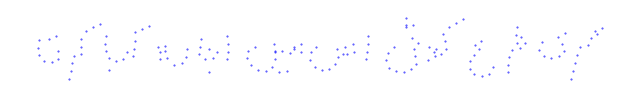

In [99]:
sample = process_sample('/content/hwd/Dataset/Data_3000/csv/csv_0004_2.csv')
print(len(sample))
plot_sample(sample)

/content/hwd/Dataset/Data_1000/csv/csv_0035_3.csv: 255 points after filtering
/content/hwd/Dataset/Data_2000/csv/csv_0032_4.csv: 192 points after filtering
/content/hwd/Dataset/Data_1500/csv/csv_0013_6.csv: 179 points after filtering
/content/hwd/Dataset/Data_1000/csv/csv_0001_2.csv: 251 points after filtering
/content/hwd/Dataset/Data_2000/csv/csv_0026_6.csv: 206 points after filtering
/content/hwd/Dataset/Data_6000/csv/csv_0029_0.csv: 198 points after filtering
/content/hwd/Dataset/Data_3000/csv/csv_0007_3.csv: 180 points after filtering
/content/hwd/Dataset/Data_6000/csv/csv_0023_5.csv: 205 points after filtering
/content/hwd/Dataset/Data_2000/csv/csv_0002_2.csv: 306 points after filtering
/content/hwd/Dataset/Data_5000/csv/csv_0046_2.csv: 203 points after filtering
/content/hwd/Dataset/Data_1000/csv/csv_0012_1.csv: 219 points after filtering
/content/hwd/Dataset/Data_3000/csv/csv_0043_6.csv: 214 points after filtering
/content/hwd/Dataset/Data_3000/csv/csv_0029_6.csv: 258 points af

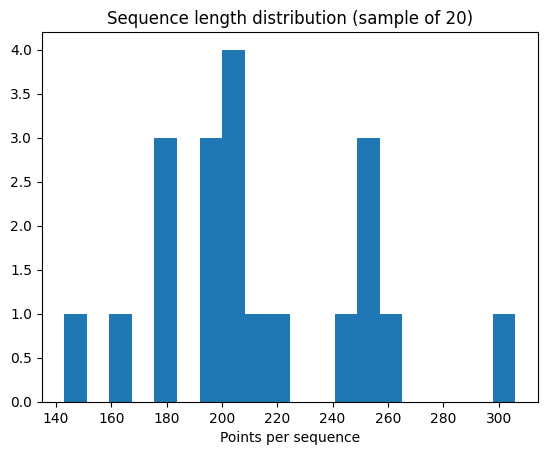

Min: 143, Max: 306, Median: 204


In [100]:
import random, matplotlib.pyplot as plt

sample = random.sample(samples, 20)

lengths = []
for p in sample:
    arr = process_sample(p)
    if arr is not None:
        lengths.append(len(arr))
        print(f"{p}: {len(arr)} points after filtering")

plt.hist(lengths, bins=20)
plt.xlabel('Points per sequence')
plt.title('Sequence length distribution (sample of 20)')
plt.show()

print(f"Min: {min(lengths)}, Max: {max(lengths)}, Median: {np.median(lengths):.0f}")